In [20]:
import pandas as pd

# ==========================================
# 1. LOAD THE RAW DATASET
# ==========================================
# Load the original Telco Customer Churn CSV file into a Pandas DataFrame
customer_data = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

# ==========================================
# 2. DATA CLEANING & TYPE CONVERSION
# ==========================================
# 'TotalCharges' is sometimes stored as a string/object because some brand-new 
# customers have blank spaces instead of numbers. 
# 'errors="coerce"' forces any unparseable values (like blank spaces) to become NaN (Not a Number).
customer_data["TotalCharges"] = pd.to_numeric(customer_data["TotalCharges"], errors="coerce")

# Fill those newly created NaN values with 0 (since new customers have $0 total charges)
customer_data["TotalCharges"] = customer_data["TotalCharges"].fillna(0)

# ==========================================
# 3. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================
# Inspect the first 10 rows to check column names, formatting, and data types visually
print(f'First 10 rows:\n{customer_data.head(10)}\n')

# Generate statistical summaries (mean, min, max, standard deviation) for numerical columns
print(f'Dataframe description:\n{customer_data.describe()}\n')

# Print structural overview: column names, count of non-null values, and data types (int, float, object)
print(f'Dataframe information:')
print(customer_data.info())
print("\n")

# Check the balance of your target variable ('Churn') to see how many customers stayed vs. left
# This is crucial for identifying class imbalance before modeling!
print(f'Churn class distribution:\n{customer_data["Churn"].value_counts()}')

First 5 rows:   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   
5  9305-CDSKC  Female              0      No         No       8          Yes   
6  1452-KIOVK    Male              0      No        Yes      22          Yes   
7  6713-OKOMC  Female              0      No         No      10           No   
8  7892-POOKP  Female              0     Yes         No      28          Yes   
9  6388-TABGU    Male              0      No        Yes      62          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service           

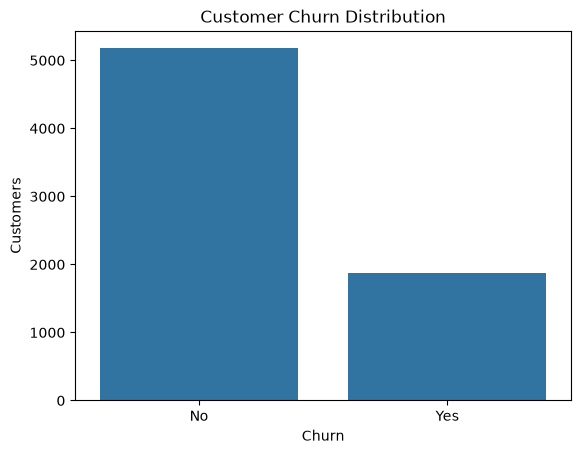

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
ax.set_ylabel('Customers')
ax.set_xlabel('Churn')
ax.set_title('Customer Churn Distribution')
sns.countplot(customer_data, x="Churn", ax=ax)
plt.show()

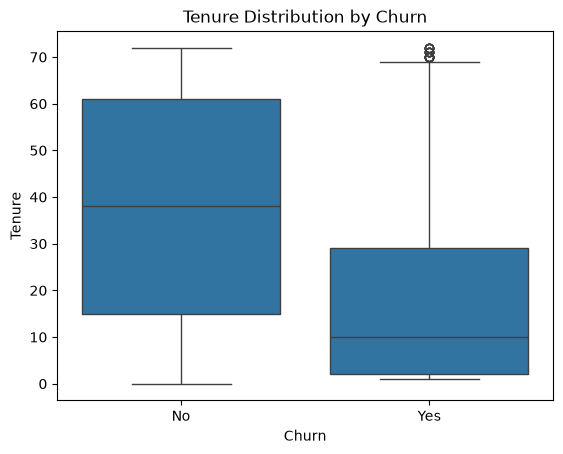

In [24]:
fig, ax = plt.subplots()
ax.set_ylabel('Tenure')
ax.set_xlabel('Churn')
ax.set_title('Tenure Distribution by Churn')
sns.boxplot(data=customer_data, x="Churn", y="tenure", ax=ax)
plt.show()

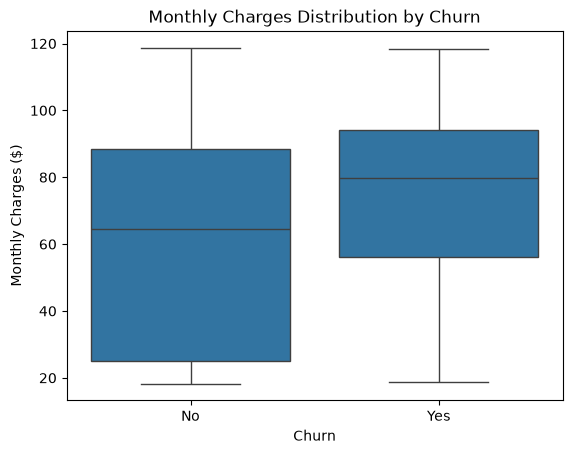

In [25]:
fig, ax = plt.subplots()
ax.set_ylabel('Monthly Charges ($)')
ax.set_xlabel('Churn')
ax.set_title('Monthly Charges Distribution by Churn')
sns.boxplot(data=customer_data, x="Churn", y="MonthlyCharges", ax=ax)
plt.show()

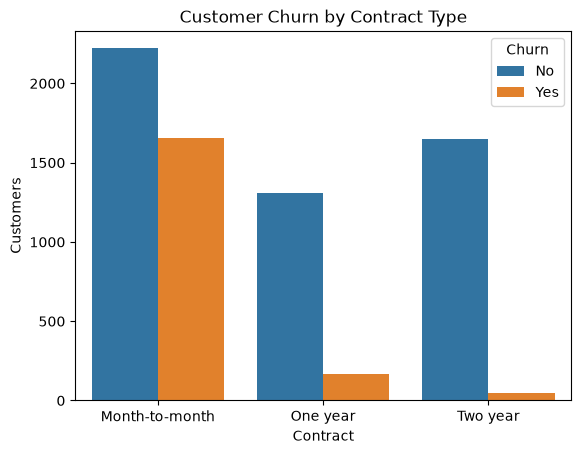

In [27]:
fig, ax = plt.subplots()
ax.set_ylabel('Customers')
ax.set_xlabel('Contract')
ax.set_title('Customer Churn by Contract Type')
sns.countplot(customer_data, x="Contract",hue="Churn", ax=ax)
plt.show()

In [28]:
from pathlib import Path
filepath = Path("../data/customer_data.csv")
filepath.parent.mkdir(parents=True, exist_ok=True)
customer_data.to_csv(filepath, index=False)